In [1]:
import model1_pipeline as m1

In [2]:
df = m1.load_data("cmu_real.csv", "vae_synthetic.csv")

Combined shape: (40800, 34)

Class counts:
label
1    20400
0    20400
Name: count, dtype: int64


In [3]:
X, y = m1.preprocess_data(df)


Dropping columns: ['subject', 'sessionIndex']

Feature shape: (40800, 31)
Label shape: (40800,)


In [4]:
X_train, X_test, y_train, y_test = m1.split_data(X, y)


Train shape: (32640, 31)
Test shape: (8160, 31)


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m1.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m1.scale_data(X_train_mi, X_test_mi)
mi_results = m1.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
      Feature     Score
12     H.five  0.569039
30   H.Return  0.542439
0    H.period  0.533194
3         H.t  0.526048
6         H.i  0.518213
18        H.o  0.515782
27        H.l  0.506299
24        H.n  0.500074
9         H.e  0.499478
15  H.Shift.r  0.488942

Model: Logistic Regression
Accuracy: 0.5878676470588236

Confusion Matrix:
[[2405 1695]
 [1668 2392]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.59      0.59      4100
           1       0.59      0.59      0.59      4060

    accuracy                           0.59      8160
   macro avg       0.59      0.59      0.59      8160
weighted avg       0.59      0.59      0.59      8160

ROC-AUC: 0.6153206175657816

Model: Linear SVM
Accuracy: 0.5877450980392157

Confusion Matrix:
[[2401 1699]
 [1665 2395]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.59      0.59    

In [6]:
X_train_anova, X_test_anova, anova_features, anova_scores = m1.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m1.scale_data(X_train_anova, X_test_anova)
anova_results = m1.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)


Top ANOVA Features:
         Feature       Score        P_Value
11     UD.e.five  791.700560  3.923599e-172
10     DD.e.five  722.279682  2.217990e-157
21           H.a  469.467358  2.243880e-103
30      H.Return  345.012292   1.284677e-76
16  DD.Shift.r.o  272.385308   6.057592e-61
17  UD.Shift.r.o  184.133108   7.881971e-42
9            H.e  140.622639   2.267690e-32
7         DD.i.e  137.324004   1.185488e-31
15     H.Shift.r  131.425479   2.284816e-30
8         UD.i.e  130.306230   4.006312e-30

Model: Logistic Regression
Accuracy: 0.6368872549019607

Confusion Matrix:
[[2511 1589]
 [1374 2686]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63      4100
           1       0.63      0.66      0.64      4060

    accuracy                           0.64      8160
   macro avg       0.64      0.64      0.64      8160
weighted avg       0.64      0.64      0.64      8160

ROC-AUC: 0.692360567103208

Model: Linear

In [7]:
X_train_corr, X_test_corr, corr_features, corr_scores = m1.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m1.scale_data(X_train_corr, X_test_corr)
corr_results = m1.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
        Feature     Score
0     UD.e.five  0.153891
1     DD.e.five  0.147142
2           H.a  0.119080
3      H.Return  0.102276
4  DD.Shift.r.o  0.090976
5  UD.Shift.r.o  0.074900
6           H.e  0.065499
7        DD.i.e  0.064729
8     H.Shift.r  0.063329
9        UD.i.e  0.063060

Model: Logistic Regression
Accuracy: 0.6368872549019607

Confusion Matrix:
[[2511 1589]
 [1374 2686]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63      4100
           1       0.63      0.66      0.64      4060

    accuracy                           0.64      8160
   macro avg       0.64      0.64      0.64      8160
weighted avg       0.64      0.64      0.64      8160

ROC-AUC: 0.692360567103208

Model: Linear SVM
Accuracy: 0.6363970588235294

Confusion Matrix:
[[2507 1593]
 [1374 2686]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61

In [8]:
X_train_var, X_test_var, var_features, var_scores = m1.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m1.scale_data(X_train_var, X_test_var)
var_results = m1.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
           Feature     Score
0        UD.e.five  0.047769
1        DD.e.five  0.047068
2  UD.five.Shift.r  0.045745
3  DD.five.Shift.r  0.045367
4           UD.i.e  0.037775
5      UD.l.Return  0.037587
6           DD.i.e  0.037156
7      DD.l.Return  0.035895
8      UD.period.t  0.033148
9      DD.period.t  0.031141

Model: Logistic Regression
Accuracy: 0.5889705882352941

Confusion Matrix:
[[2219 1881]
 [1473 2587]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.54      0.57      4100
           1       0.58      0.64      0.61      4060

    accuracy                           0.59      8160
   macro avg       0.59      0.59      0.59      8160
weighted avg       0.59      0.59      0.59      8160

ROC-AUC: 0.6360531058512555

Model: Linear SVM
Accuracy: 0.5843137254901961

Confusion Matrix:
[[2139 1961]
 [1431 2629]]

Classification Report:
              precision    recall  f1-score   support

  

In [9]:
X_train_md, X_test_md, md_features, md_scores = m1.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m1.scale_data(X_train_md, X_test_md)
md_results = m1.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
           Feature     Score
0        UD.e.five  0.067268
1        DD.e.five  0.063845
2     DD.Shift.r.o  0.025267
3           DD.i.e  0.024954
4           UD.i.e  0.024512
5     UD.Shift.r.o  0.021735
6  UD.five.Shift.r  0.021422
7  DD.five.Shift.r  0.018449
8              H.a  0.008362
9           DD.a.n  0.006492

Model: Logistic Regression
Accuracy: 0.6310049019607843

Confusion Matrix:
[[2478 1622]
 [1389 2671]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.60      0.62      4100
           1       0.62      0.66      0.64      4060

    accuracy                           0.63      8160
   macro avg       0.63      0.63      0.63      8160
weighted avg       0.63      0.63      0.63      8160

ROC-AUC: 0.686870299170972

Model: Linear SVM
Accuracy: 0.6240196078431373

Confusion Matrix:
[[2389 1711]
 [1357 2703]]

Classification Report:
              precision    recall  f1-score   suppo

In [10]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m1.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m1.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m1.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)


RFE Logistic Regression Features:
['H.period', 'H.t', 'H.e', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.Shift.r', 'DD.Shift.r.o', 'H.a', 'H.n', 'H.Return']

Model: Logistic Regression
Accuracy: 0.6254901960784314

Confusion Matrix:
[[2514 1586]
 [1470 2590]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62      4100
           1       0.62      0.64      0.63      4060

    accuracy                           0.63      8160
   macro avg       0.63      0.63      0.63      8160
weighted avg       0.63      0.63      0.63      8160

ROC-AUC: 0.6731309623933677

Model: Linear SVM
Accuracy: 0.6264705882352941

Confusion Matrix:
[[2508 1592]
 [1456 2604]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62      4100
           1       0.62      0.64      0.63      4060

    accuracy                           0.63      8160
   macro avg       0.63    

In [11]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m1.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m1.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m1.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['H.period', 'DD.period.t', 'UD.period.t', 'H.t', 'H.five', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.Shift.r', 'H.a', 'H.Return']

Model: Logistic Regression
Accuracy: 0.6685049019607843

Confusion Matrix:
[[2829 1271]
 [1434 2626]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.69      0.68      4100
           1       0.67      0.65      0.66      4060

    accuracy                           0.67      8160
   macro avg       0.67      0.67      0.67      8160
weighted avg       0.67      0.67      0.67      8160

ROC-AUC: 0.7122915415114741

Model: Linear SVM
Accuracy: 0.7034313725490197

Confusion Matrix:
[[3162  938]
 [1482 2578]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.77      0.72      4100
           1       0.73      0.63      0.68      4060

    accuracy                           0.70      8160
   macro avg       0.71   

In [12]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m1.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m1.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m1.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['DD.i.e', 'UD.i.e', 'H.e', 'UD.e.five', 'UD.five.Shift.r', 'H.Shift.r', 'UD.Shift.r.o', 'H.a', 'UD.n.l', 'UD.l.Return']

Model: Logistic Regression
Accuracy: 0.6363970588235294

Confusion Matrix:
[[2491 1609]
 [1358 2702]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63      4100
           1       0.63      0.67      0.65      4060

    accuracy                           0.64      8160
   macro avg       0.64      0.64      0.64      8160
weighted avg       0.64      0.64      0.64      8160

ROC-AUC: 0.6872596419560254

Model: Linear SVM
Accuracy: 0.6258578431372549

Confusion Matrix:
[[2402 1698]
 [1355 2705]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.59      0.61      4100
           1       0.61      0.67      0.64      4060

    accuracy                           0.63      8160
   macro avg       0.63      0.6

In [13]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m1.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m1.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m1.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)


SelectFromModel Logistic Regression Features:
            Feature       Score
0          H.period  203.312384
2       UD.period.t  200.150013
1       DD.period.t  199.726778
14  UD.five.Shift.r   23.043163
13  DD.five.Shift.r   21.553111
15        H.Shift.r   15.868040
12           H.five   14.248996
30         H.Return   11.415479
21              H.a   11.076385
3               H.t    8.096949

Model: Logistic Regression
Accuracy: 0.6685049019607843

Confusion Matrix:
[[2829 1271]
 [1434 2626]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.69      0.68      4100
           1       0.67      0.65      0.66      4060

    accuracy                           0.67      8160
   macro avg       0.67      0.67      0.67      8160
weighted avg       0.67      0.67      0.67      8160

ROC-AUC: 0.7122915415114741

Model: Linear SVM
Accuracy: 0.7034313725490197

Confusion Matrix:
[[3162  938]
 [1482 2578]]

Classification Report:
 

In [14]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m1.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m1.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m1.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)


SelectFromModel Random Forest Features:
            Feature     Score
26           UD.n.l  0.049517
11        UD.e.five  0.045484
7            DD.i.e  0.042707
14  UD.five.Shift.r  0.041454
15        H.Shift.r  0.040765
21              H.a  0.039729
8            UD.i.e  0.038798
10        DD.e.five  0.038747
17     UD.Shift.r.o  0.035348
9               H.e  0.034191

Model: Logistic Regression
Accuracy: 0.635906862745098

Confusion Matrix:
[[2501 1599]
 [1372 2688]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.61      0.63      4100
           1       0.63      0.66      0.64      4060

    accuracy                           0.64      8160
   macro avg       0.64      0.64      0.64      8160
weighted avg       0.64      0.64      0.64      8160

ROC-AUC: 0.688215306980656

Model: Linear SVM
Accuracy: 0.6275735294117647

Confusion Matrix:
[[2416 1684]
 [1355 2705]]

Classification Report:
              precision    reca

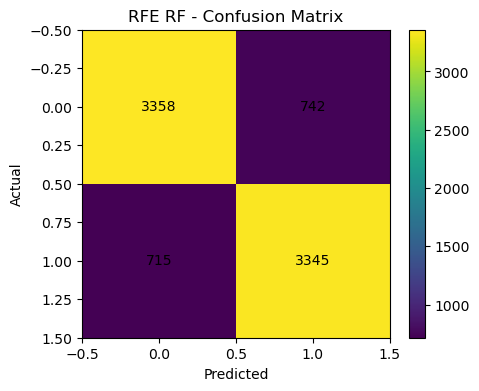

In [20]:
best_model = rfe_rf_results.iloc[0]["Model_Object"]
best_cm = rfe_rf_results.iloc[0]["Confusion_Matrix"]

m1.plot_confusion_matrix(best_cm, title="RFE RF - Confusion Matrix")

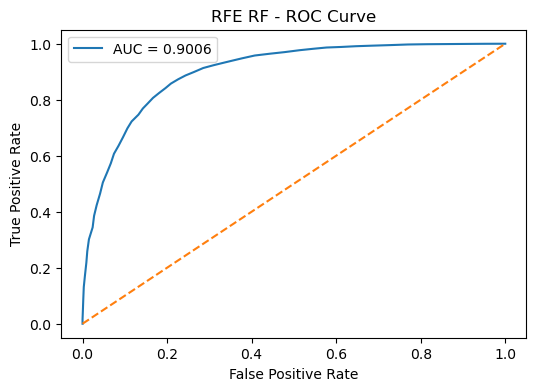

In [21]:
m1.plot_roc(best_model, X_test_rfe_rf_scaled, y_test, title="RFE RF - ROC Curve")


Feature: DD.i.e
Real Mean: 0.15937174019607844
Synthetic Mean: 0.18374238383737132
Real Std: 0.22692816883409397
Synthetic Std: 0.11901373955545104


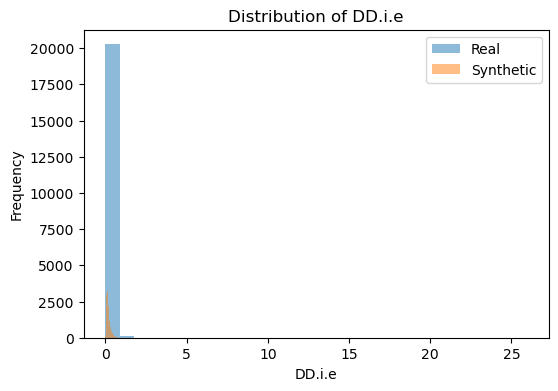

In [22]:
m1.plot_feature_distribution(df, rfe_rf_features[0])

In [23]:
m1.validate_best_model(best_model, X_train_rfe_rf_scaled, y_train)


3-Fold CV Scores: [0.81534926 0.82113971 0.82113971]
CV Mean: 0.8192095588235294


array([0.81534926, 0.82113971, 0.82113971])

In [24]:
feature_summary = m1.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)


Feature Selection Summary:
            Feature  Times_Selected
12              H.a               8
9         H.Shift.r               8
17  UD.five.Shift.r               7
16           UD.i.e               6
8               H.e               6
10        UD.e.five               6
1          H.Return               6
15           DD.i.e               6
18  DD.five.Shift.r               5
11        DD.e.five               5
14     UD.Shift.r.o               5
2          H.period               4
3               H.t               4
13     DD.Shift.r.o               4
22      DD.period.t               3
21      UD.period.t               3
0            H.five               3
7               H.n               2
19      UD.l.Return               2
24           UD.n.l               2
6               H.l               1
20      DD.l.Return               1
5               H.o               1
4               H.i               1
23           DD.a.n               1
